# Predictive Housing Price Analytics System

## Exploratory Data Analysis (EDA)

### Objective
The goal of this notebook is to understand the housing dataset, identify important features, analyze missing values, explore relationships between variables, and prepare the data for building machine learning models for house price prediction.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In this section, we load the dataset and inspect its structure.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

housing = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display first five rows

housing.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Dataset Shape

print(f"Rows : {housing.shape[0]}")
print(f"Columns : {housing.shape[1]}")

Rows : 1460
Columns : 81


In [6]:
# Dataset Information

housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Initial Observation

The dataset contains numerical as well as categorical features. The target variable is **SalePrice**, which represents the selling price of each house.

In [7]:
# Statistical Summary

housing.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [8]:
# Check Missing Values

missing_values = housing.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [9]:

# Percentage of Missing Values

missing_percentage = (housing.isnull().sum() / len(housing)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [10]:
# Duplicate Records

print("Duplicate Rows :", housing.duplicated().sum())

Duplicate Rows : 0


In [11]:
# Data Types

housing.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [12]:
# Separate Numerical and Categorical Columns

numerical_columns = housing.select_dtypes(include=["int64","float64"]).columns

categorical_columns = housing.select_dtypes(include=["object"]).columns

print(f"Numerical Features : {len(numerical_columns)}")

print(f"Categorical Features : {len(categorical_columns)}")

Numerical Features : 38
Categorical Features : 43


In [13]:
# Display Numerical Columns

numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [14]:
# Display Categorical Columns

categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## Missing Value Analysis

Before building any machine learning model, it is important to understand and handle missing values appropriately.

Some missing values in this dataset do not indicate incomplete data. Instead, they represent the absence of a particular feature (for example, a house without a pool or garage). Therefore, missing values will be handled differently depending on the meaning of each feature.

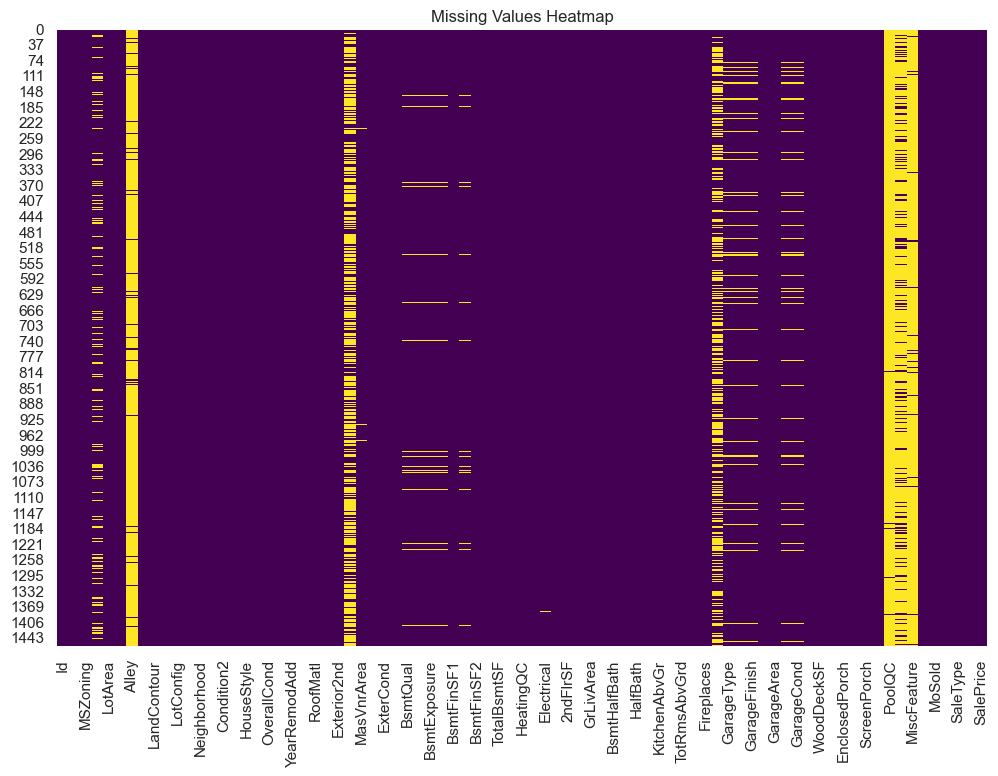

In [15]:
# ==========================================
# Visualizing Missing Values
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(housing.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

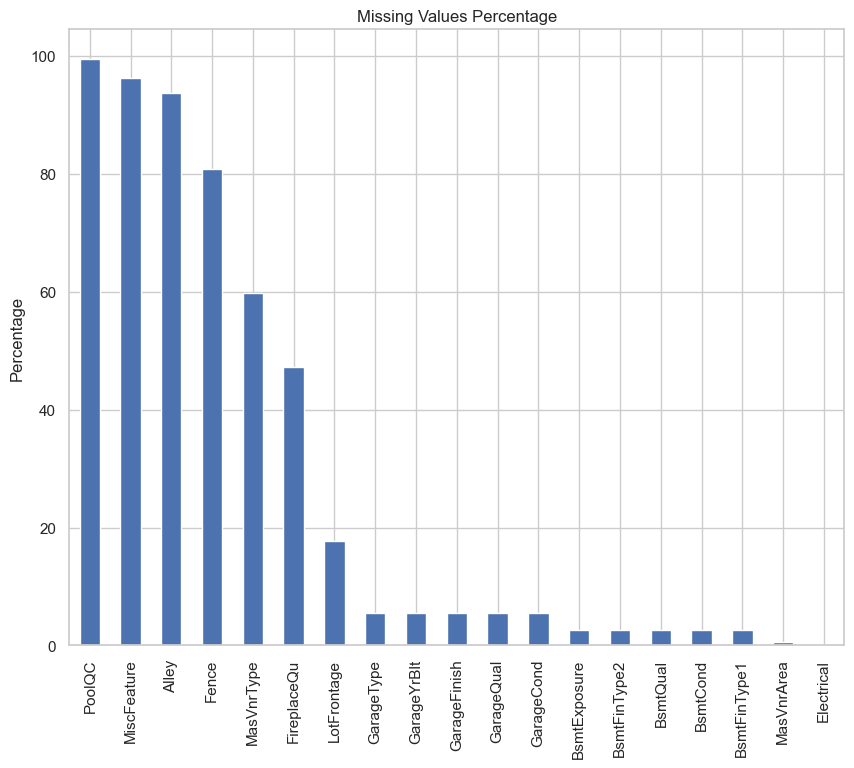

In [16]:
# Missing value percentage

missing_percentage = (
    housing.isnull().sum() /
    len(housing)
) * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

missing_percentage.plot(kind="bar")

plt.ylabel("Percentage")

plt.title("Missing Values Percentage")

plt.show()

In [18]:
# Display columns having missing values

missing_df = pd.DataFrame({
    "Missing Values": housing.isnull().sum(),
    "Percentage": (
        housing.isnull().sum() /
        len(housing)
    ) * 100
})

missing_df = missing_df[
    missing_df["Missing Values"] > 0
].sort_values(
    by="Percentage",
    ascending=False
)

missing_df

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## Exploratory Data Analysis

In this section, we explore the distribution of the target variable and analyze relationships between important features and the house sale price. These insights will help in selecting relevant features for machine learning models.

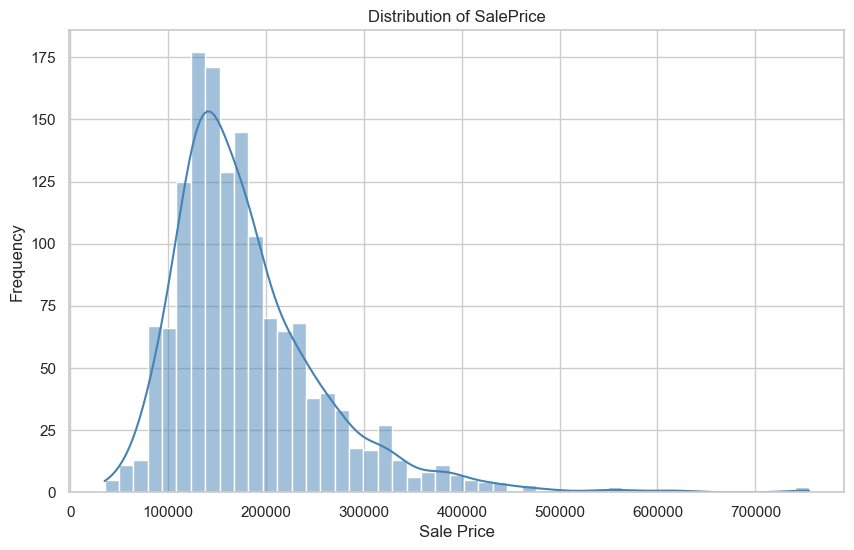

In [19]:
# ==========================================
# Distribution of SalePrice
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(housing["SalePrice"],
             kde=True,
             color="steelblue")

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of SalePrice is positively skewed. This suggests that applying a logarithmic transformation may improve model performance by making the target distribution more symmetric.

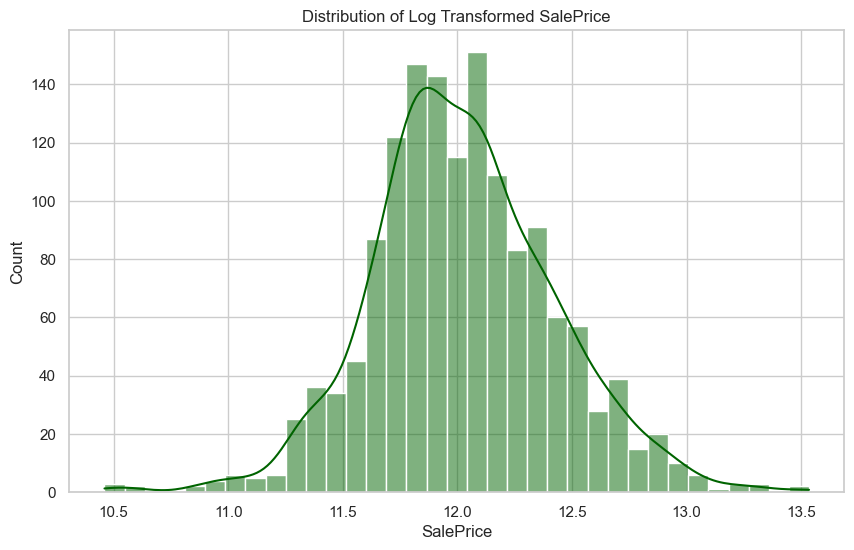

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(np.log1p(housing["SalePrice"]),
             kde=True,
             color="darkgreen")

plt.title("Distribution of Log Transformed SalePrice")

plt.show()

### Observation

The logarithmic transformation reduces skewness and makes the target variable closer to a normal distribution, which is beneficial for linear regression-based models.

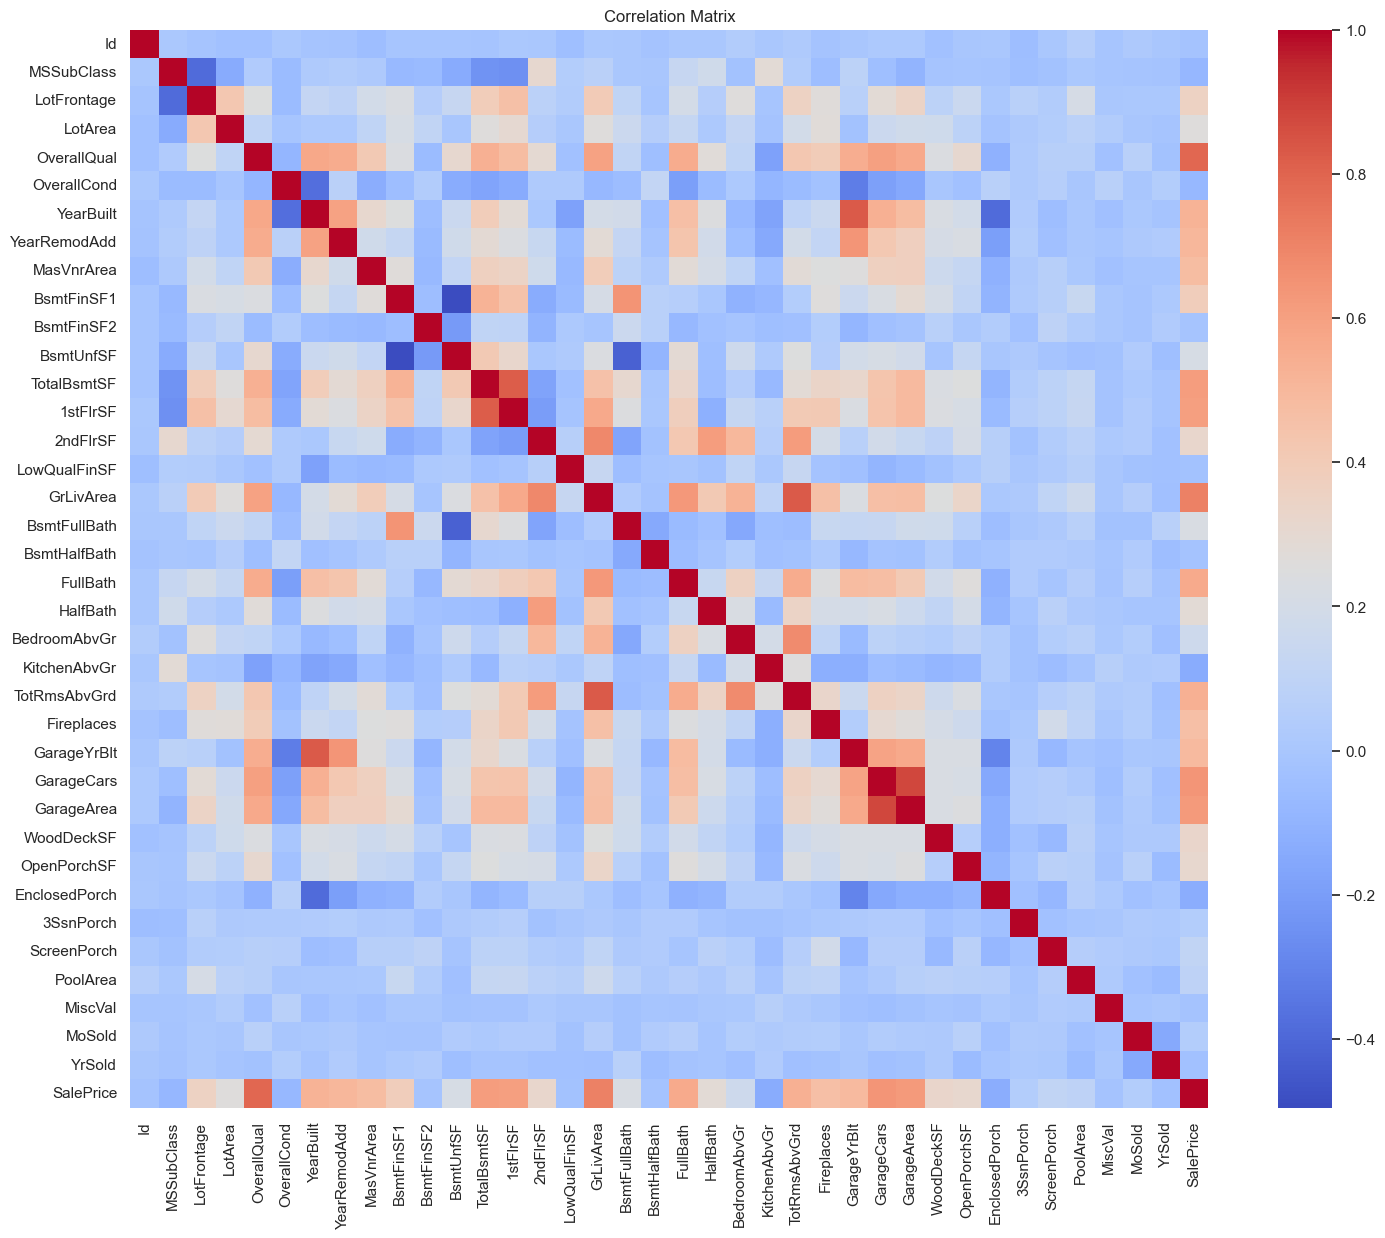

In [21]:
# Correlation between numerical features

corr_matrix = housing.corr(numeric_only=True)

plt.figure(figsize=(18,14))

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            square=True)

plt.title("Correlation Matrix")

plt.show()

In [22]:
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

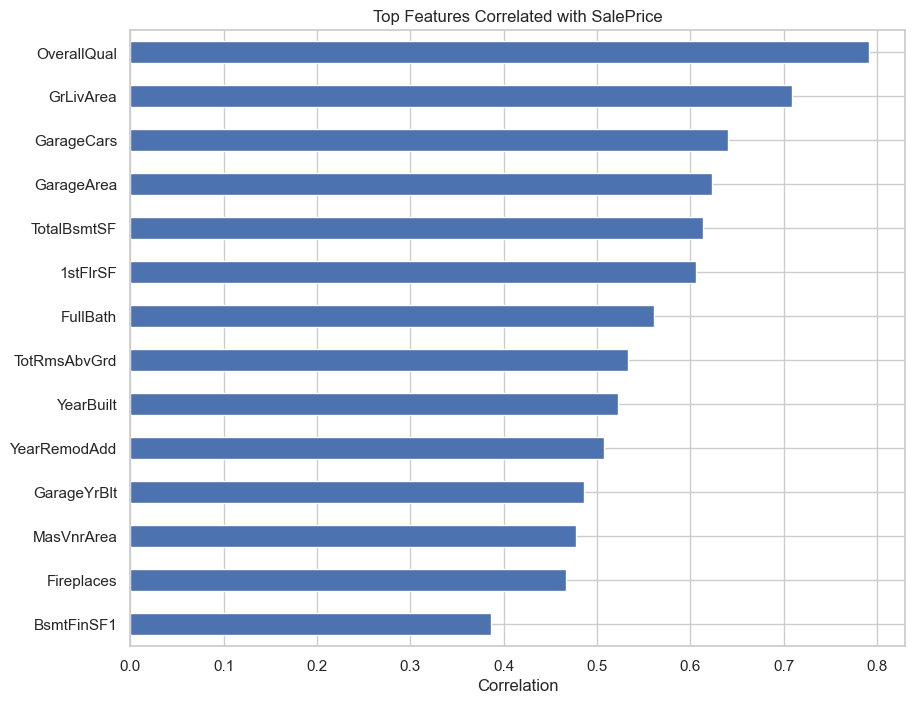

In [23]:
plt.figure(figsize=(10,8))

saleprice_corr[1:15].sort_values().plot(kind="barh")

plt.title("Top Features Correlated with SalePrice")

plt.xlabel("Correlation")

plt.show()

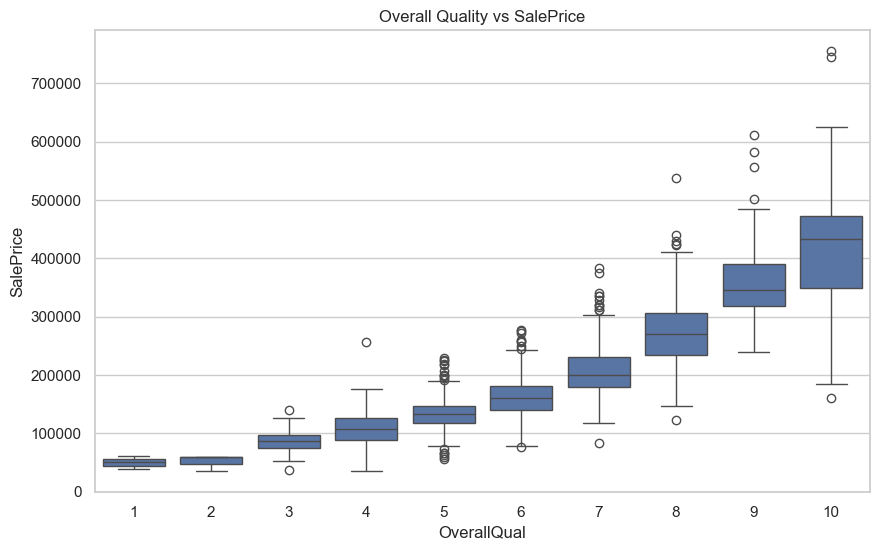

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(data=housing,
            x="OverallQual",
            y="SalePrice")

plt.title("Overall Quality vs SalePrice")

plt.show()

### Observation

Houses with higher overall quality generally have significantly higher selling prices. OverallQual is expected to be one of the strongest predictors in the machine learning models.

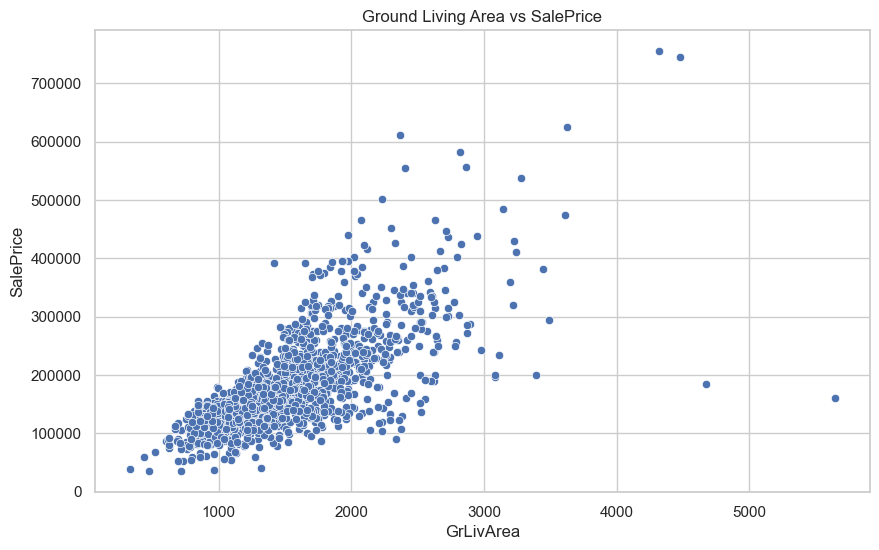

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=housing,
                x="GrLivArea",
                y="SalePrice")

plt.title("Ground Living Area vs SalePrice")

plt.show()

### Observation

There is a strong positive relationship between ground living area and the selling price. Larger homes tend to have higher market values.

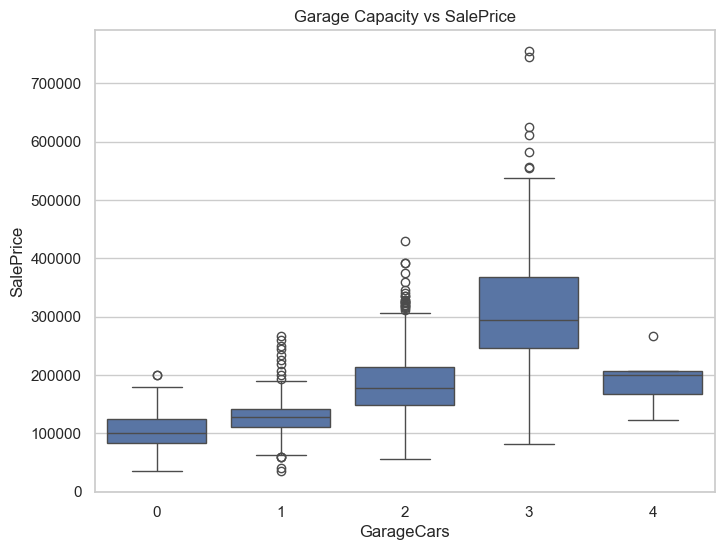

In [26]:
plt.figure(figsize=(8,6))

sns.boxplot(data=housing,
            x="GarageCars",
            y="SalePrice")

plt.title("Garage Capacity vs SalePrice")

plt.show()

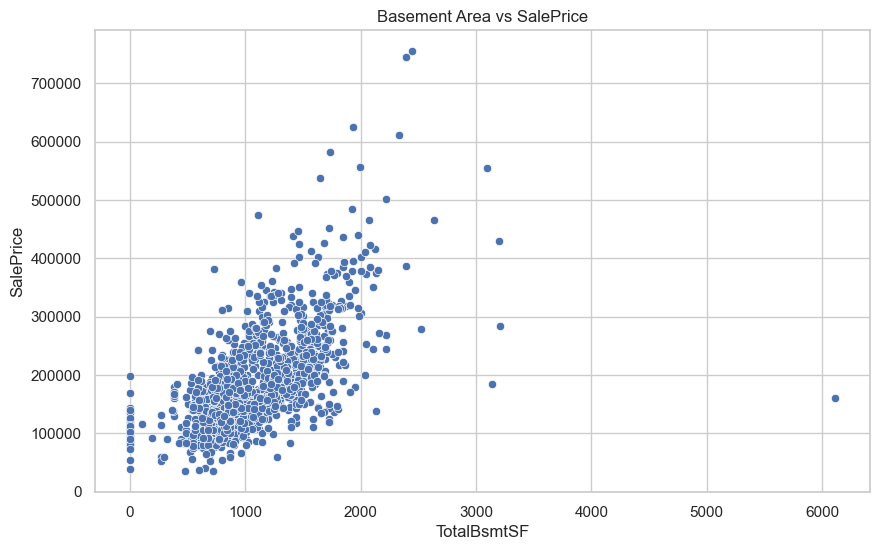

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=housing,
                x="TotalBsmtSF",
                y="SalePrice")

plt.title("Basement Area vs SalePrice")

plt.show()

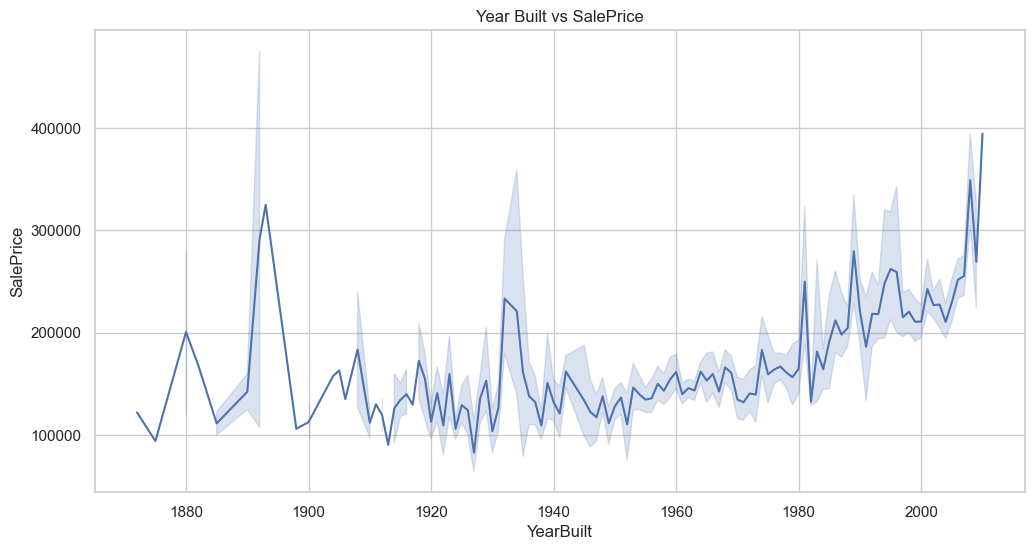

In [28]:
plt.figure(figsize=(12,6))

sns.lineplot(data=housing,
             x="YearBuilt",
             y="SalePrice")

plt.title("Year Built vs SalePrice")

plt.show()

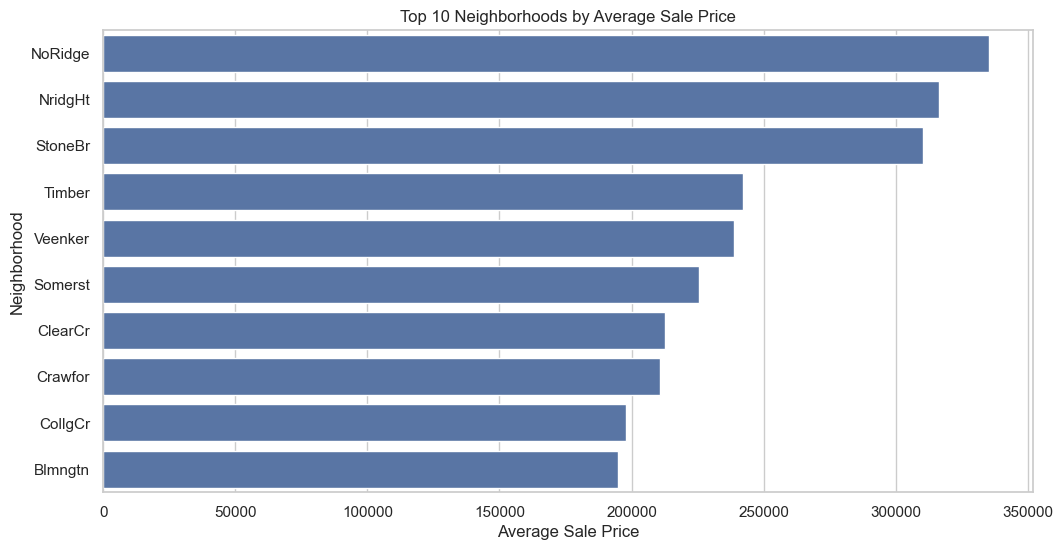

In [29]:
plt.figure(figsize=(12,6))

neighborhood_price = (
    housing.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=neighborhood_price.values[:10],
    y=neighborhood_price.index[:10]
)

plt.title("Top 10 Neighborhoods by Average Sale Price")

plt.xlabel("Average Sale Price")

plt.show()

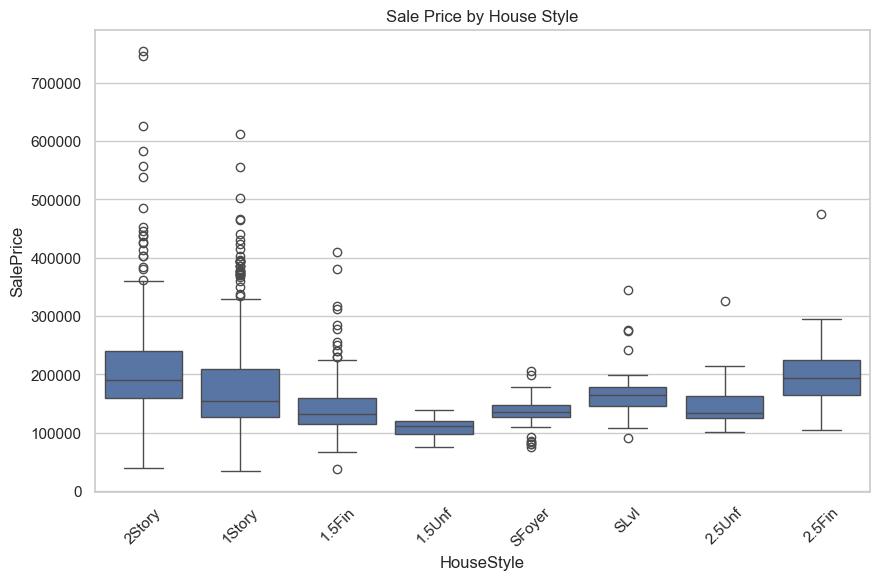

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=housing,
    x="HouseStyle",
    y="SalePrice"
)

plt.xticks(rotation=45)

plt.title("Sale Price by House Style")

plt.show()



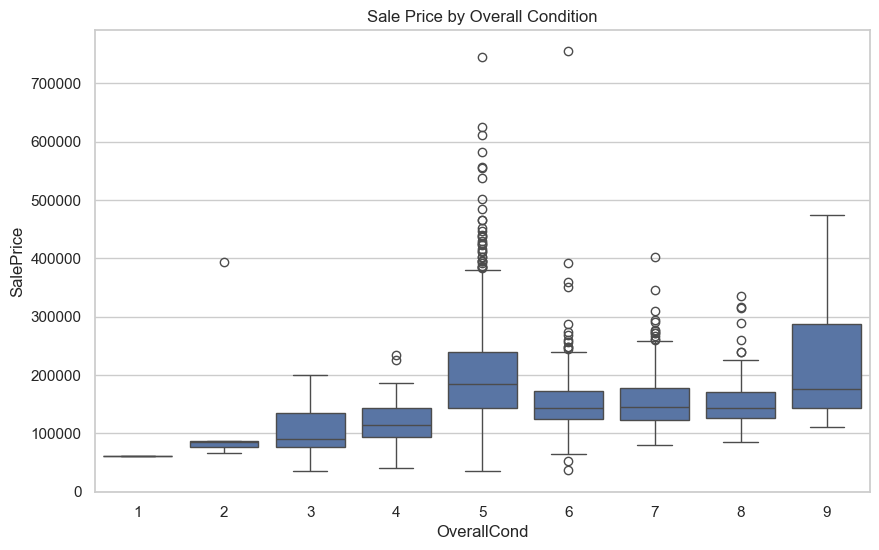

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=housing,
    x="OverallCond",
    y="SalePrice"
)

plt.title("Sale Price by Overall Condition")

plt.show()

### Key Insights

- Overall quality has the strongest positive relationship with SalePrice.
- Larger living areas generally command higher prices.
- Houses with larger garages tend to be more expensive.
- Basement size contributes positively to property value.
- Recently constructed houses generally sell for higher prices.
- Location (Neighborhood) has a significant influence on selling price.